## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

#from neuro_fuzzy_toolbox import h_ANFIS, Gaussian_MF
from neuro_fuzzy_toolbox import *

## Data

In [2]:
x_train = 2 * torch.rand(200, 3) - 1
x_train

tensor([[ 2.8502e-01,  4.4049e-01, -1.4712e-01],
        [ 3.7924e-01,  7.3873e-01,  5.5377e-01],
        [-2.3158e-01,  8.0141e-01,  3.1829e-02],
        [ 8.2293e-01,  3.5685e-01, -4.7099e-01],
        [-8.8959e-01,  6.1674e-02,  2.1839e-01],
        [ 3.4813e-01, -4.9544e-01,  7.4428e-01],
        [ 6.9092e-01,  1.8676e-01,  7.3810e-01],
        [ 9.0107e-01, -2.3671e-01,  4.0226e-01],
        [-8.7821e-04,  4.4279e-01, -2.9253e-01],
        [-3.7460e-01, -6.1300e-01,  1.9505e-01],
        [ 1.7887e-01, -9.3006e-01,  9.0499e-02],
        [-5.5917e-01, -6.6965e-01, -1.6546e-01],
        [-1.3635e-01,  3.4319e-01, -6.9650e-01],
        [-3.9903e-01,  7.0967e-01,  3.1909e-01],
        [ 1.6704e-02,  5.9434e-01, -2.2923e-01],
        [-9.3176e-01,  4.6412e-02, -4.4491e-01],
        [ 7.6878e-01,  8.7333e-01,  4.7589e-01],
        [-8.6958e-01, -6.3262e-01, -8.0319e-01],
        [-1.1719e-01, -4.7637e-02,  2.8086e-02],
        [ 5.8704e-01, -9.2837e-01, -2.4914e-01],
        [ 3.0830e-01

## Model

In [3]:
model = h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=Gaussian_MF, # Función de membresía gaussiana
    output_type='regression', # Tipo de salida: regresión
)

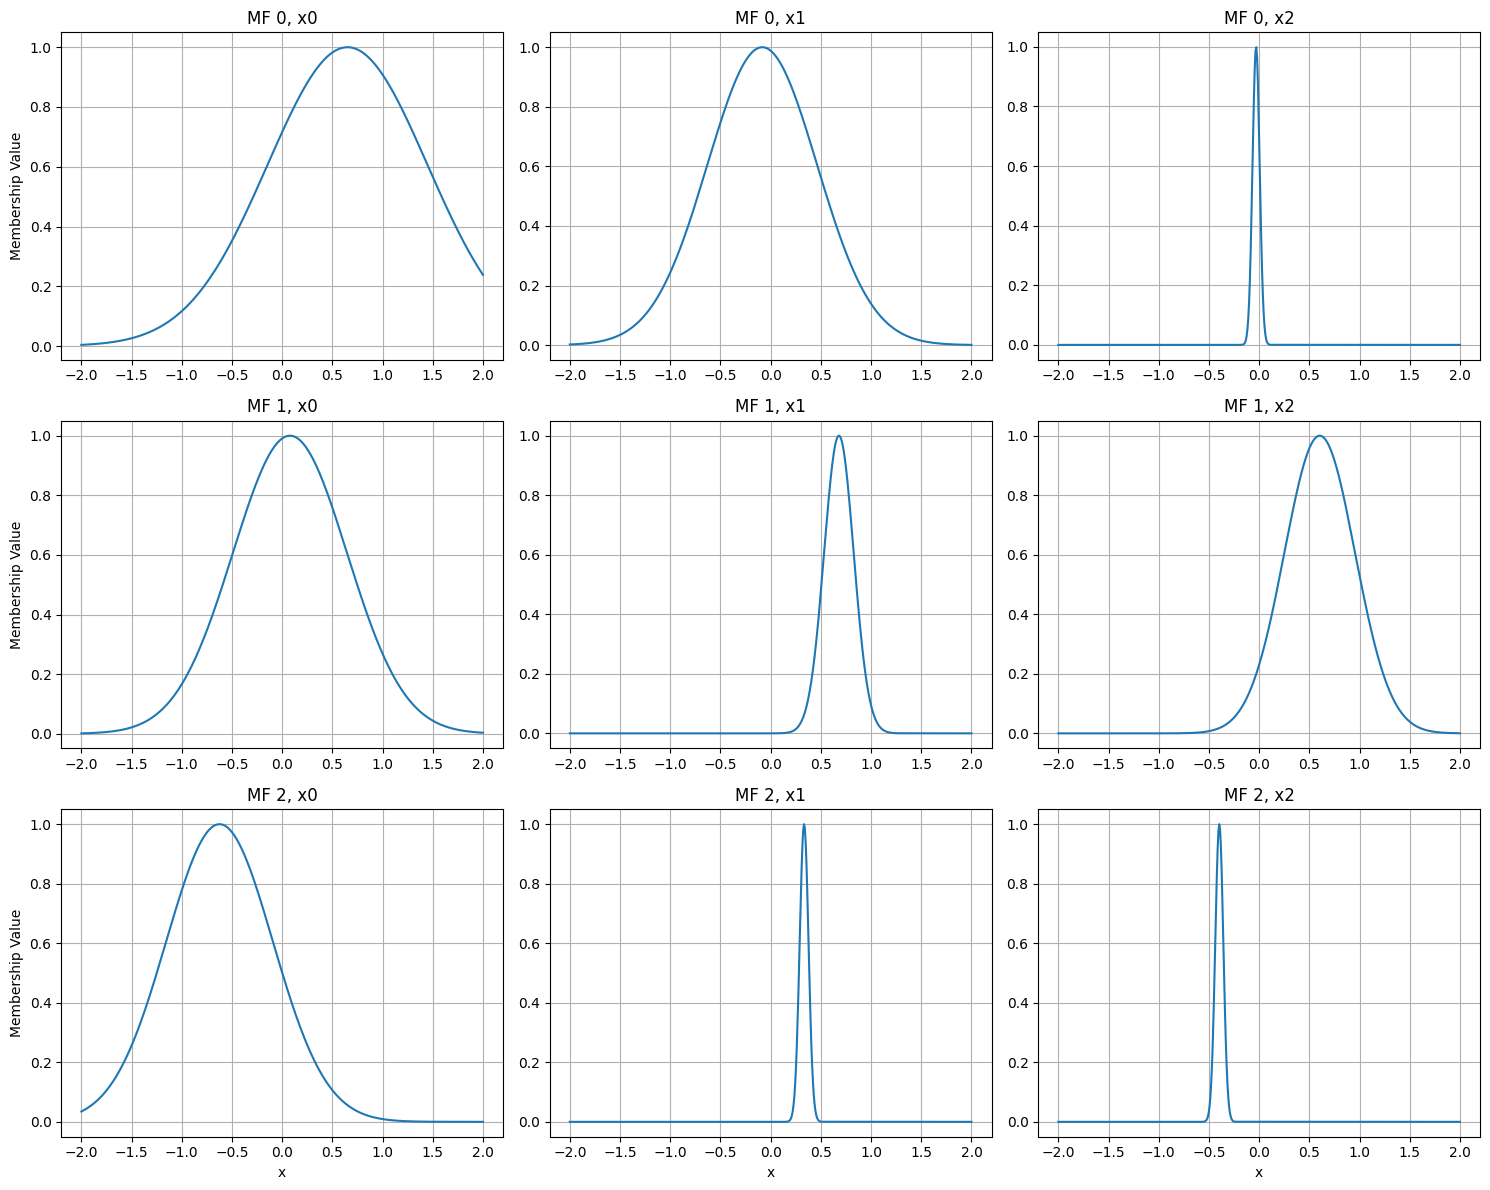

In [4]:
model.plot_premises()

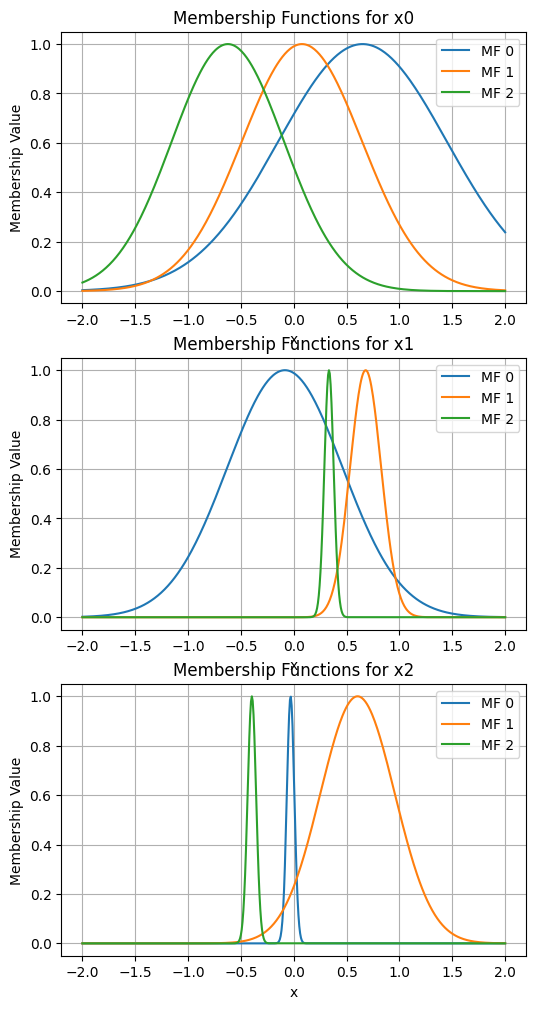

In [5]:
model.plot_premises(group_by_dim=True)

In [6]:
model.init_premises(x_train)

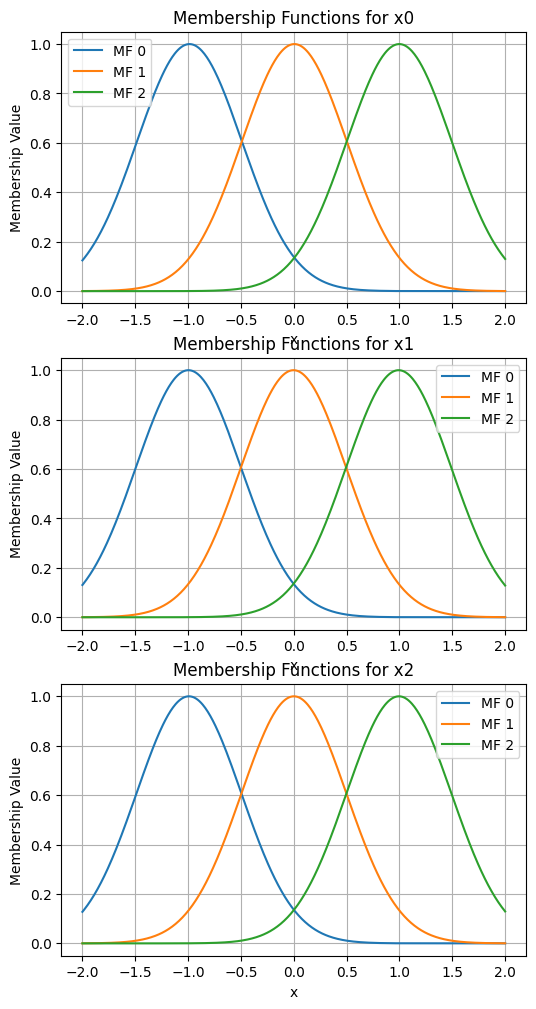

In [7]:
model.plot_premises(group_by_dim=True)

In [8]:
model.show_premises_structure()

       mu (x0)  sigma (x0)   mu (x1)  sigma (x1)   mu (x2)  sigma (x2)
MF 0 -0.986895    0.496261 -0.996619    0.497255 -0.992039    0.496774
MF 1  0.005626    0.496261 -0.002109    0.497255  0.001509    0.496774
MF 2  0.998148    0.496261  0.992402    0.497255  0.995058    0.496774


In [9]:
model.premises_structure

,mu (x0),sigma (x0),mu (x1),sigma (x1),mu (x2),sigma (x2)
MF 0,-0.986895,0.496261,-0.996619,0.497255,-0.992039,0.496774
MF 1,0.005626,0.496261,-0.002109,0.497255,0.001509,0.496774
MF 2,0.998148,0.496261,0.992402,0.497255,0.995058,0.496774


In [10]:
model.get_premises()

tensor([[[-0.9869,  0.4963],
         [ 0.0056,  0.4963],
         [ 0.9981,  0.4963]],

        [[-0.9966,  0.4973],
         [-0.0021,  0.4973],
         [ 0.9924,  0.4973]],

        [[-0.9920,  0.4968],
         [ 0.0015,  0.4968],
         [ 0.9951,  0.4968]]])

In [11]:
model.show_consequents_structure()

- Output 1:
          c0 (x0)   c1 (x1)   c2 (x2)        c3
rule 1   0.450207 -0.557199  0.082371  0.428940
rule 2  -0.871727  0.938207 -0.678892 -0.721778
rule 3  -0.837493 -0.352290  0.640985  0.937699
rule 4  -0.462834  0.756440  0.513111 -0.900420
rule 5  -0.919680  0.651620 -0.508374  0.475511
rule 6   0.791887  0.860756 -0.757221 -0.059092
rule 7   0.453064  0.641192 -0.056384 -0.359659
rule 8   0.025833 -0.013494  0.339071  0.220957
rule 9   0.526607  0.805813  0.108238  0.362475
rule 10  0.039820  0.154513  0.447283 -0.974636
rule 11  0.714045  0.447445  0.777145 -0.406345
rule 12 -0.806784 -0.368367  0.703817  0.644174
rule 13  0.981152 -0.907206 -0.769314  0.613018
rule 14 -0.544289 -0.287303 -0.966044 -0.942530
rule 15 -0.419447 -0.738879 -0.992936  0.024858
rule 16  0.179759  0.054316  0.663094  0.308767
rule 17  0.570093  0.937433 -0.129999  0.731979
rule 18 -0.059227 -0.455225  0.030031  0.713683
rule 19  0.258282 -0.625658 -0.481269 -0.549020
rule 20  0.059627 -0.815674 

In [12]:
model(x_train[:10])

tensor([ 0.0515,  0.2146,  0.5617,  0.2492,  0.4197,  0.1205,  0.0435,  0.2851,
         0.1256, -0.3293], grad_fn=<SqueezeBackward1>)

In [13]:
with torch.no_grad():
    output = model(x_train[:10])

print(output)

tensor([ 0.0515,  0.2146,  0.5617,  0.2492,  0.4197,  0.1205,  0.0435,  0.2851,
         0.1256, -0.3293])


In [14]:
model.predict(x_train[:10])

array([ 0.05152027,  0.2146402 ,  0.561749  ,  0.24923508,  0.4197383 ,
        0.12053609,  0.04348549,  0.28514066,  0.12556443, -0.32934883],
      dtype=float32)

## Binary output

In [15]:
x_train = 2 * torch.rand(200, 3) - 1

In [29]:
y_train = torch.randint(0, 2, (200,))
y_train[:10]

tensor([1, 1, 0, 0, 0, 0, 1, 1, 0, 0])

In [16]:
bin_model = h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 4 funciones de membresía
    outputs=1, # 1 salida
    membership_function=Gaussian_MF, # Función de membresía gaussiana
    output_type='binary', # Tipo de salida: clasificación binaria
)

In [17]:
bin_model.predict(x_train[:10])

array([0, 0, 1, 1, 1, 0, 0, 1, 0, 1])

In [18]:
bin_model(x_train[:10])

tensor([0.4850, 0.4174, 0.5303, 0.5792, 0.5409, 0.3680, 0.4975, 0.5391, 0.4606,
        0.5040], grad_fn=<SigmoidBackward0>)

## Multiclass output

In [109]:
x_train = 2 * torch.rand(200, 3) - 1

In [114]:
y_train = torch.randint(0, 4, (200,))
y_train[:10]

tensor([2, 3, 1, 2, 0, 2, 0, 3, 0, 3])

In [121]:
mul_class_model = h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=3, # 3 funciones de membresía
    outputs=4, # 4 clases
    membership_function=Gaussian_MF, # Función de membresía gaussiana
    output_type='multiclass', # Tipo de salida: clasificación multiclase
)

In [122]:
mul_class_model.predict(x_train[:10])

array([0, 0, 2, 1, 2, 2, 0, 1, 0, 3])

In [123]:
mul_class_model(x_train[:10])

tensor([[ 0.4425,  0.2284,  0.3152,  0.1618],
        [ 0.3934,  0.1950,  0.3640,  0.2418],
        [ 0.2840,  0.2651,  0.3129,  0.1921],
        [ 0.2482,  0.5278,  0.3655, -0.7933],
        [ 0.0890,  0.1157,  0.2529,  0.0178],
        [ 0.1855,  0.2477,  0.2571, -0.1530],
        [ 0.4424, -0.0780,  0.4180,  0.2541],
        [ 0.2046,  0.4696,  0.2142,  0.0049],
        [ 0.4243, -0.0578,  0.3322,  0.1703],
        [ 0.5209,  0.3951,  0.3004,  0.5666]], grad_fn=<SqueezeBackward1>)

In [124]:
mul_class_model(x_train[:10], return_probabilities=True)

tensor([[0.2905, 0.2345, 0.2557, 0.2194],
        [0.2739, 0.2247, 0.2660, 0.2354],
        [0.2549, 0.2501, 0.2624, 0.2325],
        [0.2632, 0.3480, 0.2959, 0.0929],
        [0.2418, 0.2483, 0.2848, 0.2251],
        [0.2597, 0.2763, 0.2789, 0.1851],
        [0.2942, 0.1749, 0.2871, 0.2437],
        [0.2420, 0.3154, 0.2443, 0.1982],
        [0.3026, 0.1868, 0.2759, 0.2347],
        [0.2680, 0.2364, 0.2150, 0.2806]], grad_fn=<SoftmaxBackward0>)

## Multiple outputs

In [101]:
x_train = 2 * torch.rand(200, 2) - 1

In [102]:
model = h_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=2, # 2 salidas
    membership_function=Gaussian_MF, # Función de membresía gaussiana
    output_type='regression', # Tipo de salida: regresión
)

In [103]:
model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.041515  0.544050 -0.547838
rule 2  0.579234  0.408734  0.428308
rule 3  0.959178 -0.230207  0.752678
rule 4 -0.269446  0.982607  0.659015
rule 5  0.276195  0.501524  0.850794
rule 6  0.369414  0.421424 -0.111580
rule 7  0.016278 -0.376643 -0.096333
rule 8  0.706941  0.326524  0.078445
rule 9 -0.427221 -0.534047 -0.654452


- Output 2:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.537603  0.692621  0.402370
rule 2  0.526148  0.665750  0.619970
rule 3  0.187756 -0.166911  0.208798
rule 4 -0.692624  0.560003 -0.146898
rule 5 -0.705729 -0.703200 -0.839496
rule 6 -0.421159 -0.275790 -0.103460
rule 7 -0.428349 -0.581571 -0.615193
rule 8  0.149810  0.810633  0.828283
rule 9  0.779135  0.535496  0.823385




In [104]:
model(x_train[:10])

tensor([[ 0.4035,  0.2029],
        [-0.1280, -0.4143],
        [ 0.5563,  0.1165],
        [ 0.9739,  0.0575],
        [ 1.4507, -1.9434],
        [ 0.3415, -0.1338],
        [-0.1835,  0.0302],
        [-0.4699,  0.0616],
        [ 0.2294, -0.0237],
        [-0.1216, -0.1168]], grad_fn=<SqueezeBackward1>)

## Multiclass problem

In [105]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

model = h_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=2, # 2 funciones de membresía
    outputs=3, # 3 salidas
    membership_function=Gaussian_MF, # Función de membresía gaussiana
    output_type='multiclass', # Tipo de salida: clasificación multiclase
)

In [106]:
model(x_train[:10])

tensor([[ 0.2742,  0.1119, -0.3300],
        [ 0.7658,  0.4833, -0.4907],
        [ 0.9230,  0.5934, -0.5340],
        [ 0.3336,  0.0938, -0.4257],
        [ 1.0164,  0.6537, -0.5635],
        [ 0.5288,  0.2697, -0.4674],
        [ 1.0368,  0.6529, -0.5789],
        [ 0.5740,  0.4910, -0.3811],
        [ 0.9838,  0.7389, -0.3988],
        [ 0.6206,  0.5498, -0.4057]], grad_fn=<SqueezeBackward1>)

In [107]:
model(x_train[:10], return_probabilities=True)

tensor([[0.4173, 0.3547, 0.2280],
        [0.4905, 0.3698, 0.1396],
        [0.5123, 0.3684, 0.1193],
        [0.4435, 0.3489, 0.2076],
        [0.5258, 0.3659, 0.1083],
        [0.4671, 0.3605, 0.1725],
        [0.5319, 0.3623, 0.1057],
        [0.4338, 0.3993, 0.1669],
        [0.4917, 0.3849, 0.1234],
        [0.4367, 0.4068, 0.1565]], grad_fn=<SoftmaxBackward0>)

In [108]:
model.predict(x_train[:10])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Rule Reduced

In [126]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

In [127]:
rr_model = h_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=3, # 3 funciones de membresía
    outputs=1, # 1 salida
    rule_reduced=True, # Reglas reducidas
)

In [128]:
rr_model.show_consequents_structure()

- Output 1:
         c0 (x0)   c1 (x1)        c2
rule 1 -0.729495 -0.345188  0.441197
rule 2  0.894614  0.420384 -0.635486
rule 3  0.235036 -0.248037  0.702353


